In [1]:
import healpy as hp
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import os
import matplotlib.pyplot as plt
from astropy.io import fits
tf.keras.backend.clear_session() #clear any previous models

data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data/simulated_data/"
os.chdir(data_directory)
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1' #disable GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  #suppress TF warnings
print("Current working directory:", os.getcwd())

2025-12-05 18:09:20.979214: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-05 18:09:35.445078: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 18:09:39.991189: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64
2025-12-05 18:09:39.991220: I 

Current working directory: /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkySimulation/data/simulated_data


In [2]:
import tensorflow as tf, sys, os
print("TF:", tf.__version__)
print("Python:", sys.version.split()[0])
print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH"))

TF: 2.10.1
Python: 3.10.15
LD_LIBRARY_PATH: /mnt/netapp1/Optcesga_FT2_RHEL7/2020/gentoo/22072020/usr/gr/lib64


Filename: ./simulated_maps/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
NSIDE: 256


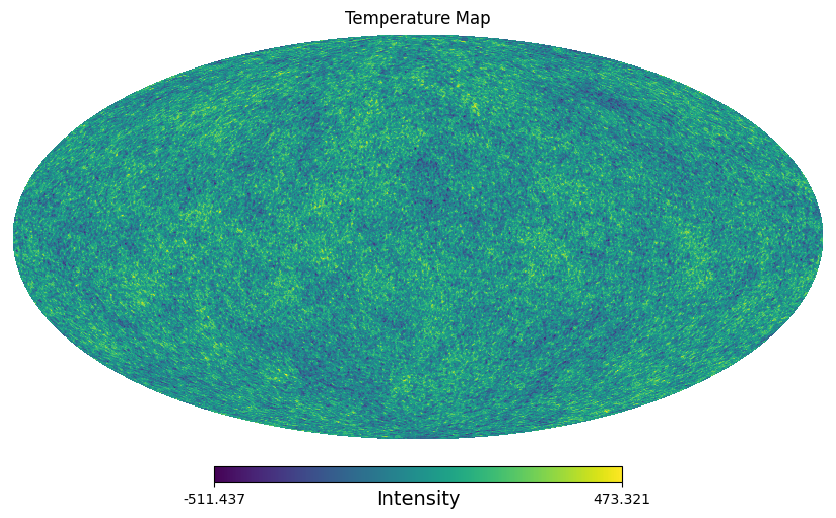

In [3]:
from SkyNeuralNets import read_map
#Read the data
path_lcdm = "./simulated_maps/"
map_temp_data = read_map(path_lcdm + 'cmb_map_0.fits')

#Visualize the map
nside = hp.npix2nside(len(map_temp_data))
#nside = 64
print(f"NSIDE: {nside}")

#Plot
hp.mollview(map_temp_data, title="Temperature Map", unit="Intensity")
plt.show()

In [4]:
def read_all_maps(path_lcdm, path_feature, n_maps=100):
    maps = []
    labels = []
    
    #LCDM maps
    for i in range(n_maps):
        map_lcdm = read_map(f"{path_lcdm}cmb_map_{i}.fits")
        maps.append(map_lcdm)
        labels.append(0)  #lcdm
    
    #Feature maps
    for i in range(n_maps):
        map_feature = read_map(f"{path_feature}cmb_map_feature_{i}.fits")
        maps.append(map_feature)
        labels.append(1)  #feature
    
    maps = np.array(maps).astype(np.float32)[..., None]  #Add channel dimension
    labels = np.array(labels).astype(np.int32)
    #print(labels)
    return maps, labels

In [5]:
def map_to_image(hp_map, xsize=256):
    #Validate that map has correct length
    hp_map = np.asarray(hp_map, dtype=np.float64)
    try:
        nside = hp.get_nside(hp_map)
    except Exception as e:
        print("Invalid map shape:", hp_map.shape)
        raise e
    img = hp.cartview(hp_map, xsize=xsize, return_projected_map=True, title="", cbar=False)
    plt.close()
    return img

In [6]:
path_feature = "./simulated_maps/"
x_raw, y_raw = read_all_maps(path_lcdm, path_feature, n_maps=225) #0: lcdm, 1:feature

Filename: ./simulated_maps/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/cmb_map_3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   768R x 1C  

In [7]:
x_raw_new = np.array(x_raw).squeeze()

In [8]:
imgs = np.array([map_to_image(m) for m in x_raw_new])
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]  #add channel dimension

In [9]:
#Compare two HEALPix maps on the sphere

#1) Mollweide full-sky view
def compare_maps_spherical(A, B, titleA="Map A", titleB="Map B", unit="μK", 
                            lon_center=0, lat_center=0, patch_size=800, patch_reso=5):
    """
    Compare two HEALPix maps on the sphere:
    - Mollweide projection for both maps and their difference
    - Zoomed gnomonic patches
    - Angular power spectra
    """
    #common scale for fair visual comparison
    vmin = np.percentile(np.concatenate([A, B]), 0.5)
    vmax = np.percentile(np.concatenate([A, B]), 99.5)
    diff = B - A

    plt.figure(figsize=(12,4))
    hp.mollview(A, title=titleA, unit=unit, min=vmin, max=vmax, cmap="coolwarm", sub=(1,3,1))
    hp.mollview(B, title=titleB, unit=unit, min=vmin, max=vmax, cmap="coolwarm", sub=(1,3,2))
    hp.mollview(diff, title=f"{titleB} - {titleA}", unit=unit, cmap="coolwarm", sub=(1,3,3))
    plt.tight_layout()


#2) Zoomed gnomonic patches

def compare_maps_patches(A, B, titleA="Map A", titleB="Map B", 
                      lon_center=0, lat_center=0, patch_size=800, patch_reso=5):
    """ Compare two HEALPix maps in zoomed patches:
    - Gnomonic projections for both maps and their difference
    - Angular power spectra (commented out)
    """
    #common scale for fair visual comparison
    vmin = np.percentile(np.concatenate([A, B]), 0.5)
    vmax = np.percentile(np.concatenate([A, B]), 99.5)
    diff = B - A

    plt.figure(figsize=(12,4))
    hp.gnomview(A, rot=(lon_center, lat_center), xsize=patch_size, reso=patch_reso, 
                title=f"{titleA} patch", cmap="coolwarm", min=vmin, max=vmax, sub=(1,3,1))
    hp.gnomview(B, rot=(lon_center, lat_center), xsize=patch_size, reso=patch_reso, 
                title=f"{titleB} patch", cmap="coolwarm", min=vmin, max=vmax, sub=(1,3,2))
    hp.gnomview(diff, rot=(lon_center, lat_center), xsize=patch_size, reso=patch_reso, 
                title="Difference patch", cmap="coolwarm", sub=(1,3,3))
    plt.tight_layout()


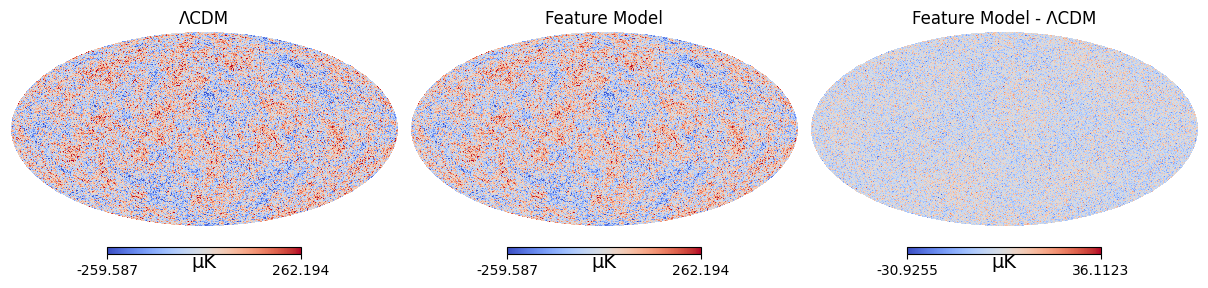

In [17]:
from SkyNeuralNets import compare_maps_spherical, compare_maps_patches
compare_maps_spherical(x_raw_new[0], x_raw_new[400], titleA="ΛCDM", titleB="Feature Model", lon_center=0, lat_center=0)
plt.savefig("/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/plots/comparison_maps.pdf", dpi=300)

/home/csic/eoy/ioj/.local/lib/python3.10/site-packages/functions/data_preprocessing.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


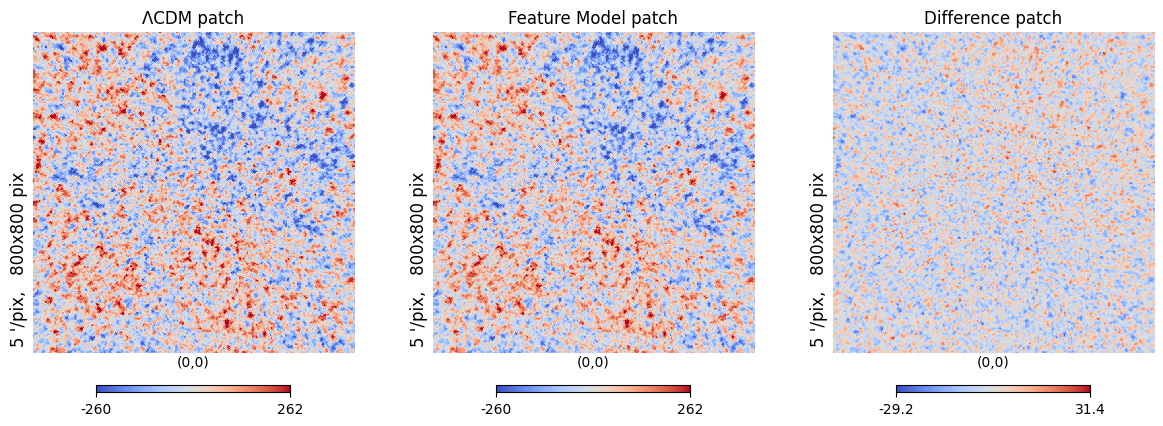

In [18]:
compare_maps_patches(x_raw_new[0], x_raw_new[400], titleA="ΛCDM", titleB="Feature Model", lon_center=0, lat_center=0)
plt.savefig("/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/plots/comparison_patches.pdf", dpi=300)

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(imgs, y_raw, test_size=0.2, random_state=15)
X_test, X_val, y_test, y_val = train_test_split(imgs, y_raw, test_size=0.2, random_state=15)

In [19]:
from sklearn.decomposition import PCA
# ---- 1. Flatten data ----
orig_shape = X_train.shape[1:]   # e.g. (H, W, 1) or (H, W)
n_features = np.prod(orig_shape)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

# ---- 2. Fit PCA on noise (Class 0 in TRAIN only) ----
n_components = 100  # or 0.999 if you want variance fraction

noise_indices = (y_train == 0)
X_noise_flat  = X_train_flat[noise_indices]

if X_noise_flat.shape[0] == 0:
    raise RuntimeError("No Class 0 maps in y_train, cannot fit PCA")

print("Fitting PCA on noise maps...")
pca = PCA(n_components=n_components, whiten=False)
pca.fit(X_noise_flat)

print(f"Explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

# ---- 3. Subtract noise from all datasets ----
def subtract_noise(X_flat, pca_obj):
    noise_part = pca_obj.inverse_transform(pca_obj.transform(X_flat))
    signal_part = X_flat - noise_part
    return noise_part, signal_part

X_train_noise_flat, X_train_signal_flat = subtract_noise(X_train_flat, pca)
X_val_noise_flat,   X_val_signal_flat   = subtract_noise(X_val_flat,   pca)
X_test_noise_flat,  X_test_signal_flat  = subtract_noise(X_test_flat,  pca)

# Reshape back
X_train_pca = X_train_signal_flat.reshape(X_train.shape).astype(np.float32)
X_val_pca   = X_val_signal_flat.reshape(X_val.shape).astype(np.float32)
X_test_pca  = X_test_signal_flat.reshape(X_test.shape).astype(np.float32)

print("PCA noise subtraction done.")

Fitting PCA on noise maps...
Explained variance: 1.0000
PCA noise subtraction done.


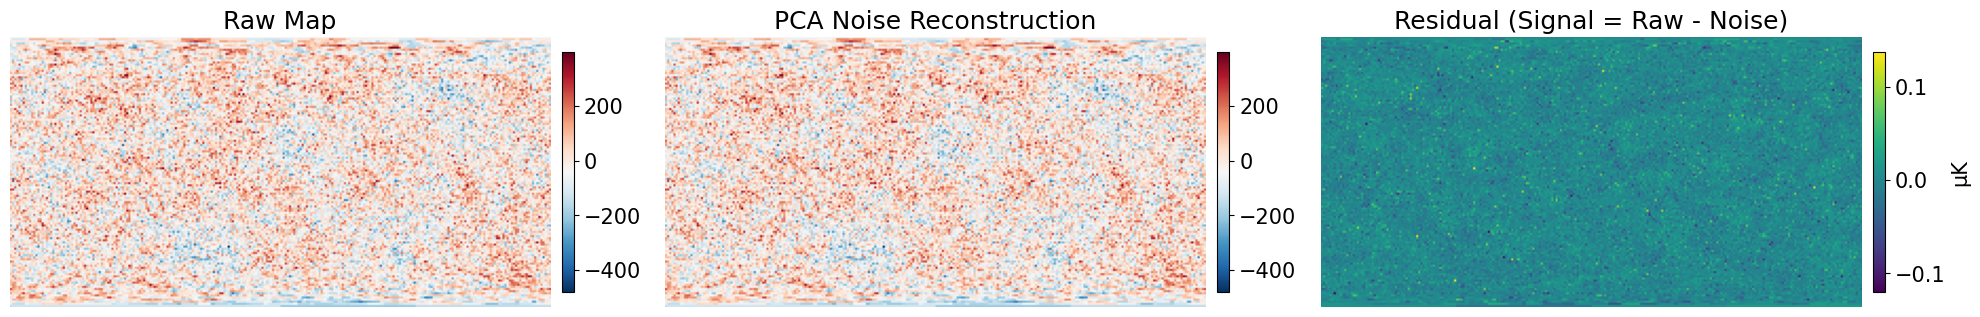

In [21]:
fsize = 18
# ---- 4. Visualize one example ----
signal_indices = np.where(y_train == 1)[0]
idx = signal_indices[0]

raw_map_flat      = X_train_flat[idx]
noise_map_flat    = X_train_noise_flat[idx]
residual_map_flat = X_train_signal_flat[idx]

# Decide how to reshape: keep same spatial dims, drop channel if present
if len(orig_shape) == 3:
    H, W, C = orig_shape
    raw_map      = raw_map_flat.reshape(H, W, C)[:, :, 0]
    noise_map    = noise_map_flat.reshape(H, W, C)[:, :, 0]
    residual_map = residual_map_flat.reshape(H, W, C)[:, :, 0]
else:
    H, W = orig_shape
    raw_map      = raw_map_flat.reshape(H, W)
    noise_map    = noise_map_flat.reshape(H, W)
    residual_map = residual_map_flat.reshape(H, W)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# lock scale between raw and noise
vmin = min(raw_map.min(), noise_map.min())
vmax = max(raw_map.max(), noise_map.max())

im1 = axes[0].imshow(raw_map, cmap='RdBu_r', vmin=vmin, vmax=vmax, origin='lower')
axes[0].set_title(f"Raw Map", fontsize=fsize)
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.08, pad=0.02, shrink=0.42)
cbar1.ax.tick_params(labelsize=15) 
axes[0].axis("off")

im2 = axes[1].imshow(noise_map, cmap='RdBu_r', vmin=vmin, vmax=vmax, origin='lower')
axes[1].set_title("PCA Noise Reconstruction", fontsize=fsize)
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.08, pad=0.02, shrink=0.42)
cbar2.ax.tick_params(labelsize=15)
axes[1].axis("off")

im3 = axes[2].imshow(residual_map, cmap='viridis', origin='lower')
axes[2].set_title("Residual (Signal = Raw - Noise)", fontsize=fsize)
cbar3 = plt.colorbar(im3, ax=axes[2], fraction=0.08, pad=0.02, shrink=0.42)
cbar3.ax.tick_params(labelsize=15) 
cbar3.set_label("µK", fontsize=15)
axes[2].axis("off")

plt.tight_layout()
plt.savefig("/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/SkyNeuralNets/plots/PCA_noise_subtraction.pdf", dpi=300)
plt.show()